In [1]:
import scanpy as sc

In [2]:
import pandas as pd

In [3]:
import scvi

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ribo_genes = pd.read_table('/Users/qiaoqiaowan/Desktop/python/KEGG_RIBOSOME.v2026.1.Hs.txt', skiprows=2, header = None) #connection to local file, you can also directly read from the url using pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [5]:
import numpy as np

In [6]:
def pp(csv_path): #input the path of the raw count csv file, output the preprocessed adata after doublet removal and quality control filtering
    adata = sc.read_csv(csv_path).T
    sc.pp.filter_genes(adata, min_cells = 10)
    sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')
    scvi.model.SCVI.setup_anndata(adata)
    vae = scvi.model.SCVI(adata)
    vae.train()
    solo = scvi.external.SOLO.from_scvi_model(vae)
    solo.train()
    df = solo.predict()
    df['prediction'] = solo.predict(soft = False)
    df.index = df.index.map(str)
    df['dif'] = df.doublet - df.singlet
    doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
    
    adata = sc.read_csv(csv_path).T
    adata.obs['Sample'] = csv_path.split('_')[2] #'raw_counts/GSM5226574_C51ctr_raw_counts.csv'
    
    adata.obs['doublet'] = adata.obs.index.isin(doublets.index)
    adata = adata[~adata.obs.doublet]
    
    
    sc.pp.filter_cells(adata, min_genes=200) #get rid of cells with fewer than 200 genes
    #sc.pp.filter_genes(adata, min_cells=3) #get rid of genes that are found in fewer than 3 cells
    adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
    adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)
    upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
    adata = adata[adata.obs.n_genes_by_counts < upper_lim]
    adata = adata[adata.obs.pct_counts_mt < 20]
    adata = adata[adata.obs.pct_counts_ribo < 2]

    return adata

In [7]:
import os
import scanpy as sc
import scvi as scvi
import pandas as pd

In [8]:
out = []
for file in os.listdir('/Users/qiaoqiaowan/Desktop/python/scRNA-seq/raw_counts/'):
    out.append(pp('raw_counts/' + file))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [06:44<00:00,  1.04it/s, v_num=1, train_loss=305]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [06:44<00:00,  1.01s/it, v_num=1, train_loss=305]
INFO     Creating doublets, preparing SOLO model.                                                                  


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connect

...

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [05:46<00:00,  1.15it/s, v_num=1, train_loss=326]
INFO     Creating doublets, preparing SOLO model.                                                                  


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connect

Epoch 301/400:  75%|███████▌  | 301/400 [01:05<00:21,  4.61it/s, v_num=1, train_loss_step=0.244, train_loss_epoch=0.256]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.245. Signaling Trainer to stop.


/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify a

In [9]:
adata = sc.concat(out)

In [10]:
adata

AnnData object with n_obs × n_vars = 42648 × 34546
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'

In [11]:
sc.pp.filter_genes(adata, min_cells = 10)

In [12]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(42648, 27061), dtype=float32)

In [13]:
from scipy.sparse import csr_matrix

In [14]:
adata.X = csr_matrix(adata.X)

In [15]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 38852731 stored elements and shape (42648, 27061)>

In [16]:
adata.write_h5ad('/Users/qiaoqiaowan/Desktop/python/scRNA-seq/combined.h5ad')

In [17]:
############### Normalization and clustering after data integration

In [18]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

In [19]:
adata = sc.read_h5ad('/Users/qiaoqiaowan/Desktop/python/scRNA-seq/combined.h5ad')
adata

AnnData object with n_obs × n_vars = 42648 × 27061
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [20]:
adata.obs.groupby('Sample').count()

/var/folders/m6/46ff4qfn7zj41m5q1v2jsc140000gp/T/ipykernel_41539/2340059915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Sample').count()


,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
Sample,,,,,,,,
C51ctr,5960,5960,5960,5960,5960,5960,5960,5960
C52ctr,4415,4415,4415,4415,4415,4415,4415,4415
C53ctr,6928,6928,6928,6928,6928,6928,6928,6928
C54ctr,4284,4284,4284,4284,4284,4284,4284,4284
C55ctr,5565,5565,5565,5565,5565,5565,5565,5565
C56ctr,3904,3904,3904,3904,3904,3904,3904,3904
C57ctr,4687,4687,4687,4687,4687,4687,4687,4687
L01cov,2952,2952,2952,2952,2952,2952,2952,2952
L03cov,3953,3953,3953,3953,3953,3953,3953,3953


In [21]:
sc.pp.filter_genes(adata, min_cells = 100)

In [22]:
adata

AnnData object with n_obs × n_vars = 42648 × 18448
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [23]:
adata.layers['counts'] = adata.X.copy()

In [24]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [25]:
adata.obs.head()

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TCATATCTCTTCTAAC-1_5,C55ctr,False,1535,1535,4616.0,0.0,0.0,0.0,0.000000
TGCAGTAAGGCCACCT-1_5,C55ctr,False,1476,1476,4428.0,0.0,0.0,3.0,0.067751
CGGGACTAGTCACTCA-1_5,C55ctr,False,1607,1607,3857.0,0.0,0.0,1.0,0.025927
ACCTGTCCAGGGTCTC-1_5,C55ctr,False,1592,1592,3913.0,0.0,0.0,0.0,0.000000
CACAGGCTCGCATTGA-1_5,C55ctr,False,1603,1603,3685.0,0.0,0.0,3.0,0.081411


In [26]:
adata

AnnData object with n_obs × n_vars = 42648 × 18448
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [27]:
scvi.model.SCVI.setup_anndata(adata, layer = "counts",
                             categorical_covariate_keys=["Sample"],
                             continuous_covariate_keys=['pct_counts_mt', 'total_counts', 'pct_counts_ribo'])

In [28]:
model = scvi.model.SCVI(adata)

In [29]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 188/188: 100%|██████████| 188/188 [4:24:30<00:00, 85.42s/it, v_num=1, train_loss=2.98e+3]  

`Trainer.fit` stopped: `max_epochs=188` reached.


Epoch 188/188: 100%|██████████| 188/188 [4:24:30<00:00, 84.42s/it, v_num=1, train_loss=2.98e+3]


In [30]:
adata.obsm['X_scVI'] = model.get_latent_representation()

In [31]:
adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size = 1e4)

In [32]:
sc.pp.neighbors(adata, use_rep = 'X_scVI')

In [33]:
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.5)

/var/folders/m6/46ff4qfn7zj41m5q1v2jsc140000gp/T/ipykernel_41539/4004962361.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


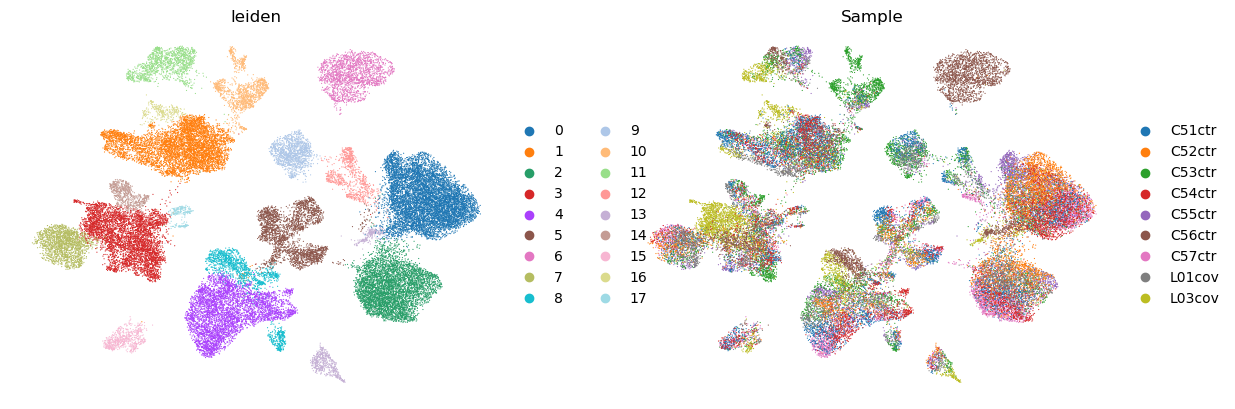

In [34]:
sc.pl.umap(adata, color = ['leiden', 'Sample'], frameon = False)

In [35]:
adata.write_h5ad('integrated.h5ad')

In [36]:
#######find markers/label cell types

In [37]:
sc.tl.leiden(adata, resolution = 1)

In [40]:
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',
    method='wilcoxon'
)

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages

In [41]:
markers = sc.get.rank_genes_groups_df(adata, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,SFTPB,112.258499,7.609036,0.000000,0.000000
1,0,LRRK2,106.066376,6.657030,0.000000,0.000000
2,0,ZNF385B,105.433929,6.523751,0.000000,0.000000
3,0,ANK3,99.211334,4.898793,0.000000,0.000000
4,0,PDE4D,98.015358,4.687054,0.000000,0.000000
...,...,...,...,...,...,...
462207,25,RELCH,2.866030,0.985648,0.004157,0.049059
462208,25,NSRP1,2.864876,0.965444,0.004172,0.049207
462209,25,DHTKD1,2.863479,2.124611,0.004190,0.049393
462210,25,LIG1,2.861839,2.362046,0.004212,0.049618


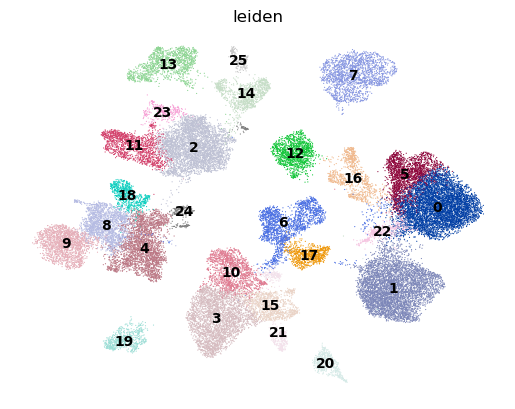

In [42]:
sc.pl.umap(adata, color = ['leiden'], frameon = False, legend_loc = "on data")

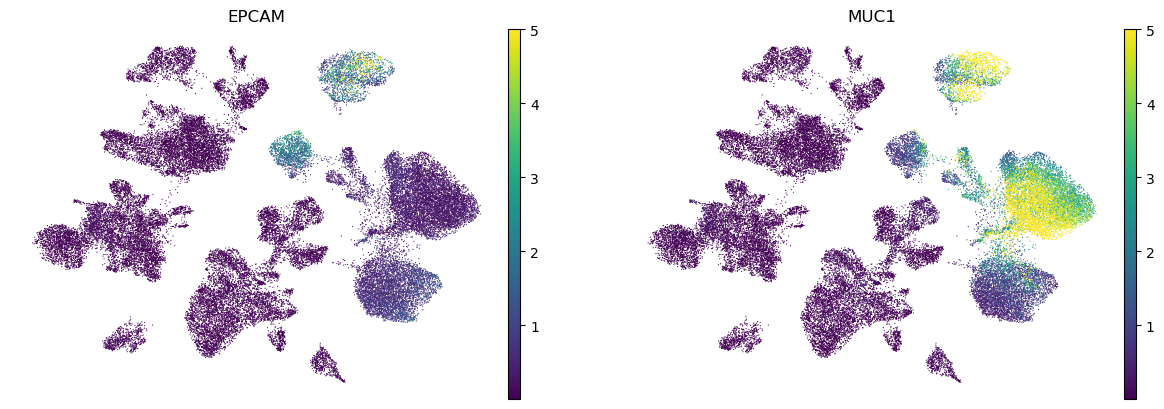

In [43]:
sc.pl.umap(adata, color = ['EPCAM', 'MUC1'], frameon = False, layer = 'scvi_normalized', vmax = 5)

In [44]:
cell_type = {"0":"Macrophage",
"1":"Fibroblast",
"2":"CD4+ T-cell",
"3":"AT2",
"4":"AT1",
"5":"CD8+ T-cell",
"6":"Endothelial cell",
"7":"Plasma cell",
"8":"Macrophage",
"9":"AT2",
"10":"Fibroblast",
"11":"Fibroblast",
"12":"Macrophage",
"13":"Macrophage",
"14":"Airway epithelial",
"15":"Airway epithelial",
"16":"Monocyte",
"17":"Airway epithelial",
"18":"B-cell",
"19":"Aerocyte",
"20":"Airway epithelial",
"21":"Smooth muscle cell",
"22":"Cycling T/NK",
"23":"Neuronal cell",
"24":"Denditic cell",
"25":"Pericyte",
"26":"Fibroblast",
"27":"Erythroid-like",
"28":"Macrophage"
}

In [45]:
adata.obs['cell type'] = adata.obs.leiden.map(cell_type)

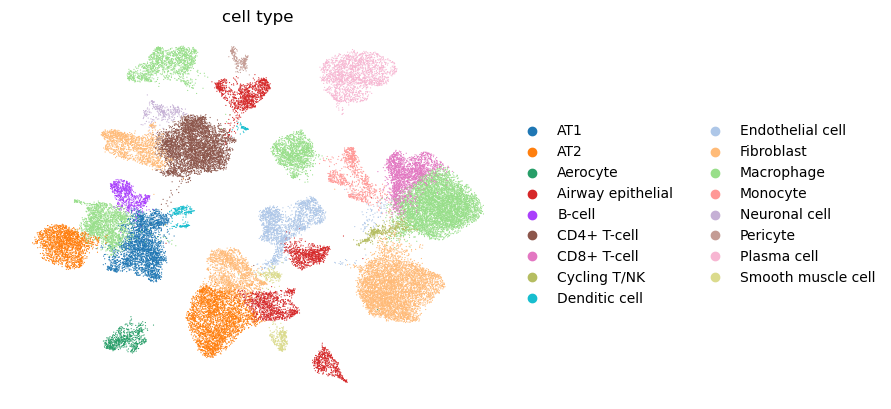

In [46]:
sc.pl.umap(adata, color = ['cell type'], frameon = False)

In [47]:
adata

AnnData object with n_obs × n_vars = 42648 × 18448
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'cell type'
    var: 'n_cells'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Sample_colors', 'rank_genes_groups', 'cell type_colors'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

In [ ]:
markers_scvi = model.differential_expression(
    groupby='leiden'
)
markers_scvi.columns

DE...: 100%|██████████| 26/26 [14:39<00:00, 33.84s/it]


Index(['proba_m1', 'proba_m2', 'bayes_factor', 'scale1', 'scale2', 'raw_mean1',
       'raw_mean2', 'non_zeros_proportion1', 'non_zeros_proportion2',
       'raw_normalized_mean1', 'raw_normalized_mean2', 'comparison', 'group1',
       'group2'],
      dtype='object')

In [52]:
import numpy as np

markers_scvi['log2fc'] = np.log2(
    (markers_scvi['raw_normalized_mean1'] + 1e-8) /
    (markers_scvi['raw_normalized_mean2'] + 1e-8)
)

In [53]:


markers_scvi_filtered = markers_scvi[
    (markers_scvi['bayes_factor'] > 3) &
    (markers_scvi['log2fc'] > 0.5)
]

markers_scvi_filtered

,proba_m1,proba_m2,bayes_factor,scale1,scale2,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,comparison,group1,group2,log2fc
AC010998.1,0.9962,0.0038,5.568944,0.000638,0.000019,0.978949,0.024692,0.504809,0.016830,6.779897,0.152596,0 vs Rest,0,Rest,5.473475
SNX30,0.9960,0.0040,5.517450,0.000797,0.000093,1.173822,0.138753,0.557249,0.094973,7.661697,0.814721,0 vs Rest,0,Rest,3.233287
PGC,0.9956,0.0044,5.421739,0.000563,0.000012,0.729815,0.013895,0.374887,0.009425,5.286346,0.096892,0 vs Rest,0,Rest,5.769745
AC105206.1,0.9940,0.0060,5.109976,0.000133,0.000003,0.144076,0.002397,0.113772,0.002100,1.063821,0.014105,0 vs Rest,0,Rest,6.236926
AC024257.3,0.9932,0.0068,4.984008,0.000091,0.000007,0.108511,0.008805,0.097079,0.008482,0.713413,0.058638,0 vs Rest,0,Rest,3.604820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KLRB1,0.9528,0.0472,3.005011,0.000082,0.000013,0.139423,0.008294,0.105769,0.007422,0.738748,0.094003,25 vs Rest,25,Rest,2.974312
PPP6R2,0.9528,0.0472,3.005011,0.000402,0.000229,0.677885,0.312856,0.403846,0.240716,4.321125,2.293673,25 vs Rest,25,Rest,0.913747
LINC01684,0.9526,0.0474,3.000573,0.000083,0.000017,0.057692,0.028676,0.043269,0.022691,0.431453,0.166379,25 vs Rest,25,Rest,1.374729
AP001347.1,0.9526,0.0474,3.000573,0.000190,0.000034,0.341346,0.041965,0.264423,0.032752,1.886195,0.287068,25 vs Rest,25,Rest,2.716014


In [54]:
adata.uns['scvi_markers'] = markers_scvi
adata.uns['markers'] = markers

In [55]:
adata.write_h5ad('integrated.h5ad')

In [56]:
model.save('model.model')